DATASET LOADED SUCCESSFULLY
Shape: (9800, 18)

First 5 Rows:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     F

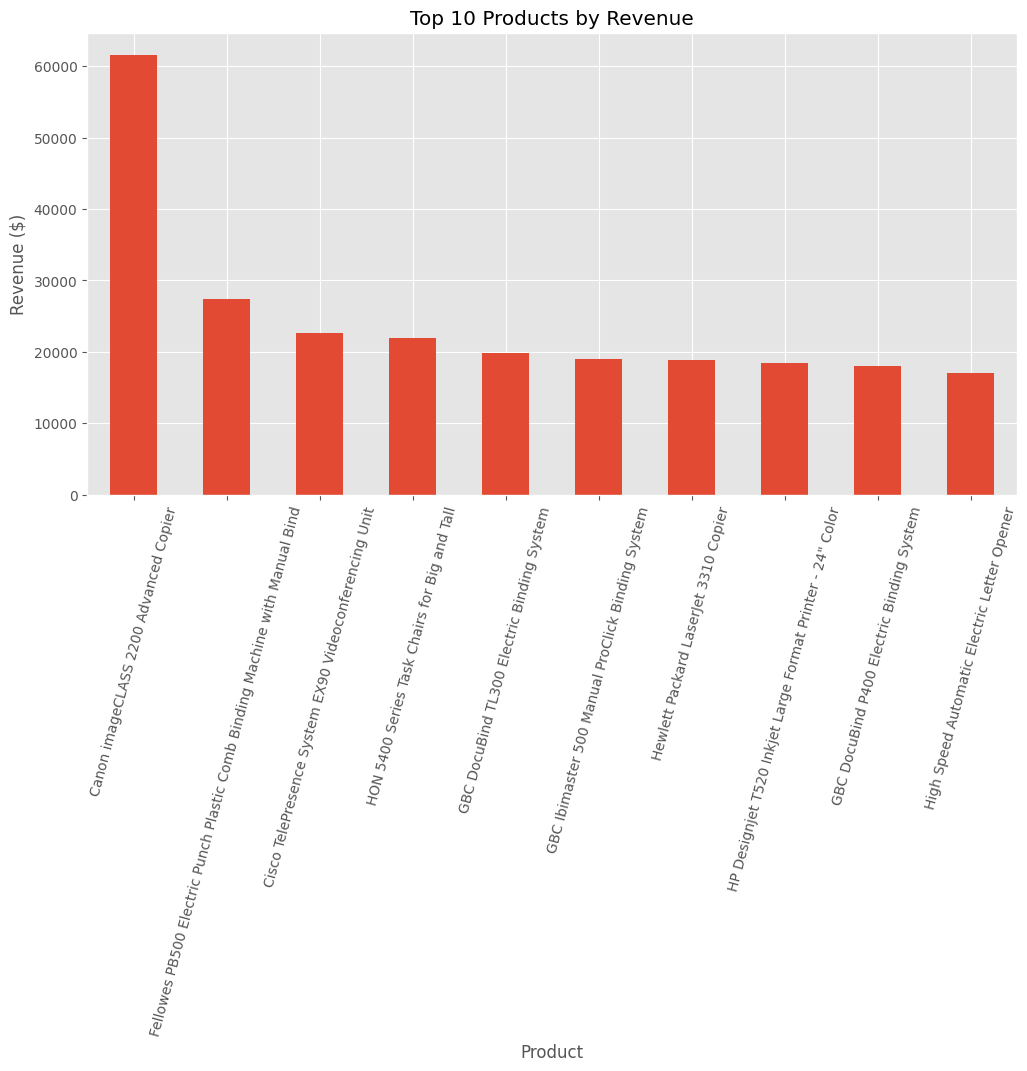

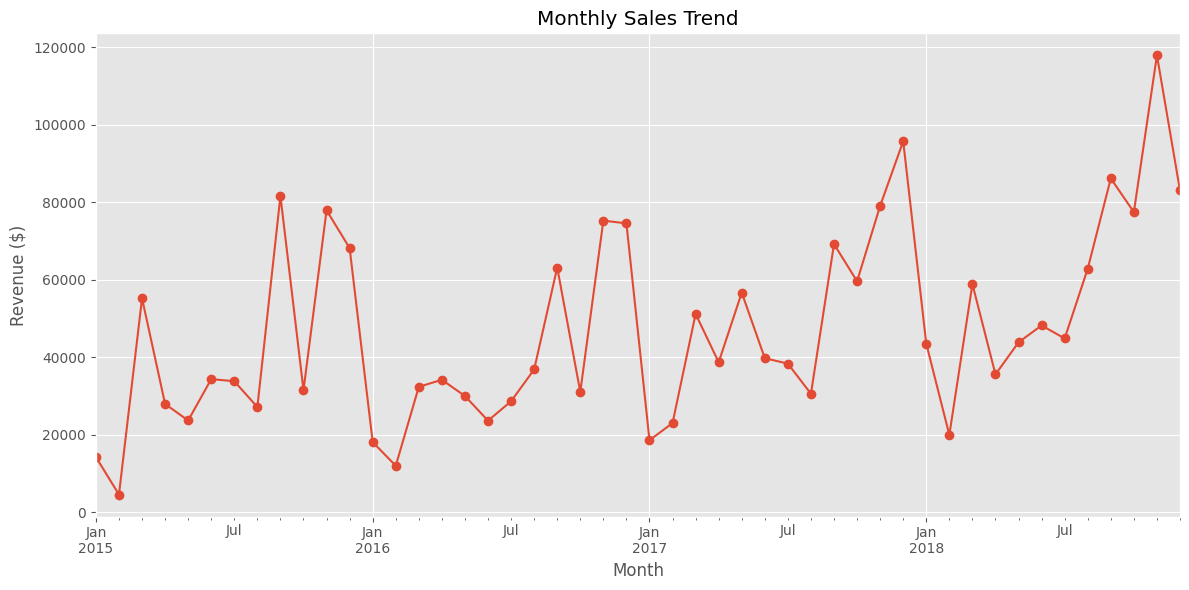

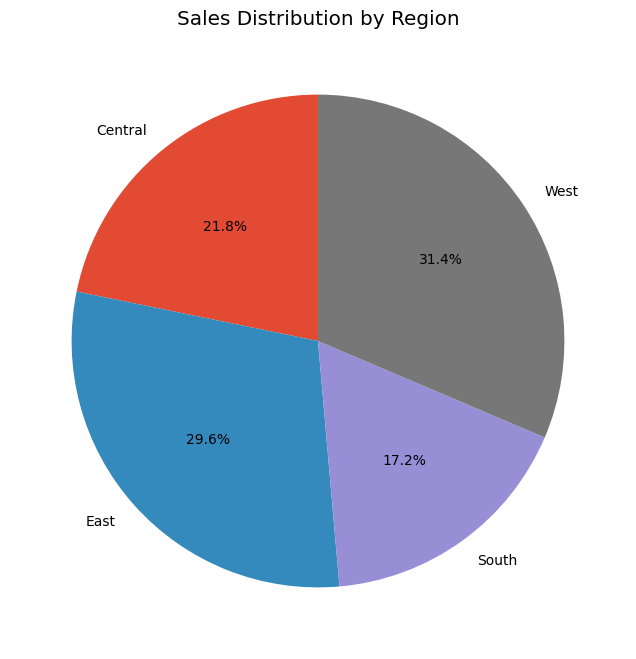

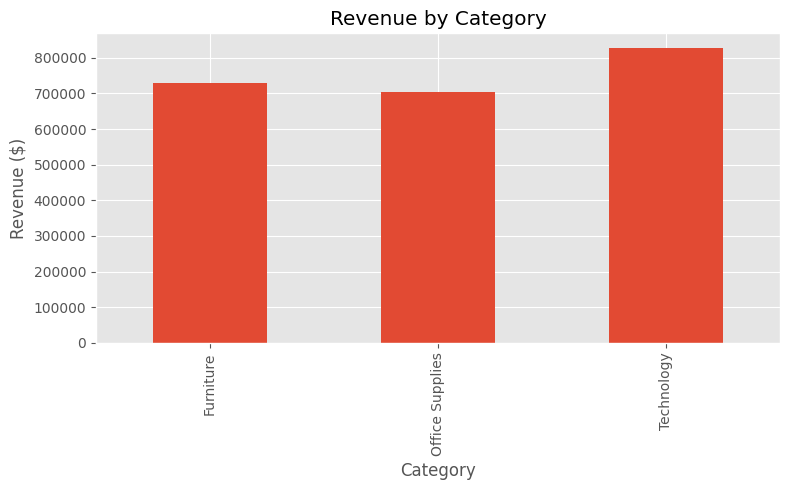

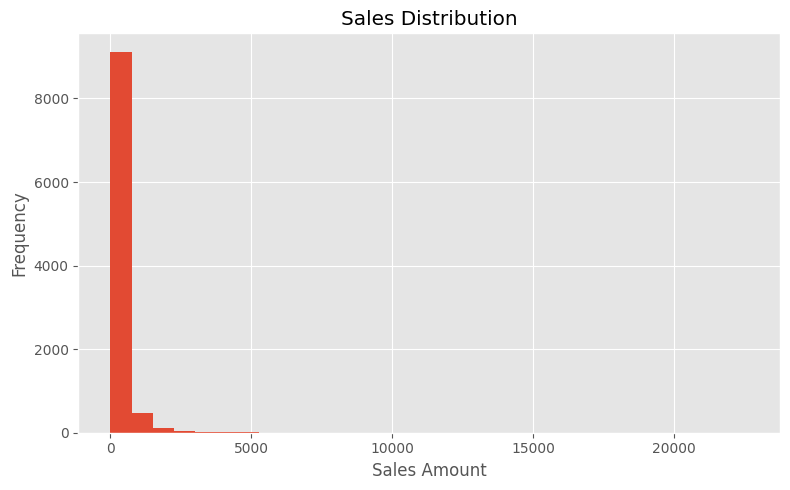


CATEGORY ANALYSIS
                 Total_Revenue  Total_Orders  Average_Sale
Category                                                  
Furniture          728658.5757          2078    350.653790
Office Supplies    705422.3340          5909    119.381001
Technology         827455.8730          1813    456.401474

REGION ANALYSIS
             Revenue  Orders
Region                      
West     710219.6845    3140
East     669518.7260    2785
Central  492646.9132    2277
South    389151.4590    1598


 SALES ANALYSIS REPORT 
Total Records           : 9800
Date Range              : 2015-01-03 to 2018-12-30
Total Revenue           : $2,261,536.78
Average Sale            : $230.77
Median Sale             : $54.49

Top 5 Products By Revenue
Product
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit              

In [6]:
# CloudExify Data Science Month 1 - Project 1
# Sales Data Analysis (Complete Solution)
# Dataset: train.csv (Sample Superstore)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')

# 1. Load Dataset

df = pd.read_csv("train.csv")

print("="*70)
print("DATASET LOADED SUCCESSFULLY")
print("="*70)
print("Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe(include='all'))

# 2. Data Cleaning

print("\n" + "="*70)
print("DATA CLEANING")
print("="*70)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()


df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True) 

# Rename columns according to project guide
df = df.rename(columns={
    'Order Date':'Date',
    'Product Name':'Product',
    'Sales':'Amount'
})

# Create Units column (dataset has no Quantity)
df['Units'] = 1

print("\nData Types:")
print(df.dtypes)

# 3. Exploratory Data Analysis

print("\n" + "="*70)
print("EXPLORATORY DATA ANALYSIS")
print("="*70)

print(f"Total Revenue : ${df['Amount'].sum():,.2f}")
print(f"Average Sale  : ${df['Amount'].mean():,.2f}")
print(f"Median Sale   : ${df['Amount'].median():,.2f}")
print(f"Maximum Sale  : ${df['Amount'].max():,.2f}")
print(f"Minimum Sale  : ${df['Amount'].min():,.2f}")
print(f"Std Deviation : ${df['Amount'].std():,.2f}")

print("\nTop 10 Products (Frequency)")
print(df['Product'].value_counts().head(10))

print("\nTop 10 Products by Revenue")
top_products = df.groupby('Product')['Amount'].sum().sort_values(ascending=False)
print(top_products.head(10))

# 4. Visualizations

# Top Products
plt.figure(figsize=(12,6))
top_products.head(10).plot(kind='bar')
plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

# Monthly Sales Trend
monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum()

plt.figure(figsize=(12,6))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Sales by Region
region_sales = df.groupby('Region')['Amount'].sum()

plt.figure(figsize=(8,8))
plt.pie(region_sales,
        labels=region_sales.index,
        autopct='%1.1f%%',
        startangle=90)
plt.title("Sales Distribution by Region")
plt.show()

# Category Revenue
category_sales = df.groupby('Category')['Amount'].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()

# Histogram
plt.figure(figsize=(8,5))
plt.hist(df['Amount'], bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 5. Category Analysis

print("\n" + "="*70)
print("CATEGORY ANALYSIS")
print("="*70)

category_analysis = df.groupby('Category').agg(
    Total_Revenue=('Amount','sum'),
    Total_Orders=('Units','sum'),
    Average_Sale=('Amount','mean')
)

print(category_analysis)

# 6. Region Analysis

print("\n" + "="*70)
print("REGION ANALYSIS")
print("="*70)

region_analysis = df.groupby('Region').agg(
    Revenue=('Amount','sum'),
    Orders=('Units','sum')
).sort_values(by='Revenue', ascending=False)

print(region_analysis)

# 7. Best Month

monthly_summary = df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum()

best_month = monthly_summary.idxmax()
best_month_sales = monthly_summary.max()

# 8. Final Report

print("\n")
print("="*70)
print(" SALES ANALYSIS REPORT ")
print("="*70)

print(f"Total Records           : {len(df)}")
print(f"Date Range              : {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Total Revenue           : ${df['Amount'].sum():,.2f}")
print(f"Average Sale            : ${df['Amount'].mean():,.2f}")
print(f"Median Sale             : ${df['Amount'].median():,.2f}")

print("\nTop 5 Products By Revenue")
print(df.groupby('Product')['Amount'].sum().nlargest(5))

print("\nRevenue by Category")
print(category_analysis['Total_Revenue'])

print("\nRevenue by Region")
print(region_analysis['Revenue'])

print(f"\nBest Sales Month        : {best_month}")
print(f"Revenue in Best Month   : ${best_month_sales:,.2f}")

print("\nKey Insights")
print("- Technology products generate high revenue.")
print("- West and East regions contribute significantly to total sales.")
print("- Monthly sales fluctuate across the year.")
print("- A small number of products contribute a large share of revenue.")
print("- Category-wise analysis helps identify profitable business segments.")

print("\nCompleted Successfully!")
print("="*70)